PART 1: Random vectors of X and Y

Custom Least Squares
m = -0.249875, b = 0.525237
MSE = 0.076679
R^2 = 0.068135
Residuals:
[-0.49013869  0.48365212  0.34619094 -0.21930963 -0.19382228 -0.19162892
 -0.0440652   0.18242633  0.12314364  0.0035517 ]
Largest residual: -0.490139 at point (X=0.0581, Y=0.0206)
Smallest residual: 0.003552 at point (X=0.9507, Y=0.2912)

NumPy Least Squares
m = -0.249875, b = 0.525237
MSE = 0.076679
R^2 = 0.068135
Residuals:
[-0.49013869  0.48365212  0.34619094 -0.21930963 -0.19382228 -0.19162892
 -0.0440652   0.18242633  0.12314364  0.0035517 ]
Largest residual: -0.490139 at point (X=0.0581, Y=0.0206)
Smallest residual: 0.003552 at point (X=0.9507, Y=0.2912)


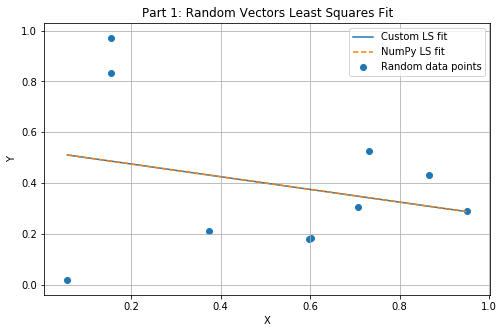


PART 2: Synthetic linear data with random error
Original equation: y = 2.7x + -0.4

Custom Least Squares
m = 2.865215, b = -0.514160
MSE = 0.348302
R^2 = 0.667049
Residuals:
[ 0.33786565 -0.60850457 -0.30485514 -0.1580729   0.01969123  0.67625104
 -0.49640547  0.13106369  0.2857718  -0.80780866  0.31272807 -0.56296554
 -0.77556275  0.99045299  1.02229383  0.70617231 -0.30304699 -0.71858245
  0.45288722 -0.03692599 -0.67480666  0.06981854 -0.85341038  0.89480123
 -0.40793176  0.39790069 -0.30537387  0.10968787  0.16132024 -0.56404356
  1.00376463  0.61320887  0.94028896  0.84929363  0.25378674  0.9000831
 -0.76833251 -0.55500394 -0.85816724 -0.29961331 -0.17457154 -0.4108802
  0.7022446  -0.24337591 -0.39666569  0.1252053  -0.67999056  0.6409028
 -0.81604202  1.00697841  0.57604193 -0.5726684  -0.96070768  0.6575188
  0.43865848  0.48130598  0.56418019 -0.83192335 -0.26473335 -0.75157884
  0.74123775  0.259975   -0.32647735 -0.86280885 -0.36961306 -0.34286321
  0.46433036  0.27858079  

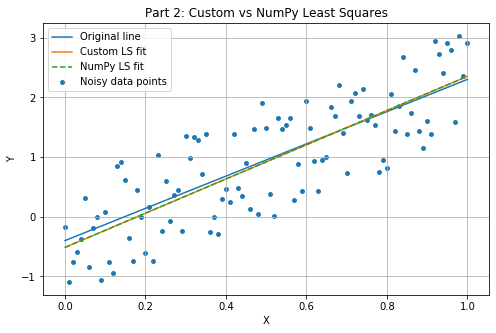

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def my_least_squares(X, Y):
    A = np.vstack([X, np.ones(len(X))]).T
    ATA = A.T @ A
    ATY = A.T @ Y
    coeffs = np.linalg.inv(ATA) @ ATY
    m, b = coeffs[0], coeffs[1]
    return m, b

#NumPy Least Squares Method

def numpy_least_squares(X, Y):
    A = np.vstack([X, np.ones(len(X))]).T
    m, b = np.linalg.lstsq(A, Y, rcond=None)[0]
    return m, b

def residuals(X, Y, m, b):
    Y_pred = m * X + b
    r = Y - Y_pred
    return Y_pred, r

def print_results(name, X, Y, m, b):
    Y_pred, r = residuals(X, Y, m, b)

    mse = np.mean((Y - Y_pred)**2)
    ss_res = np.sum((Y - Y_pred)**2)
    ss_tot = np.sum((Y - np.mean(Y))**2)
    r2 = 1 - ss_res / ss_tot

    largest_index = np.argmax(np.abs(r))
    smallest_index = np.argmin(np.abs(r))

    print(f"\n{name}")
    print(f"m = {m:.6f}, b = {b:.6f}")
    print(f"MSE = {mse:.6f}")
    print(f"R^2 = {r2:.6f}")
    print("Residuals:")
    print(r)
    print(f"Largest residual: {r[largest_index]:.6f} at point (X={X[largest_index]:.4f}, Y={Y[largest_index]:.4f})")
    print(f"Smallest residual: {r[smallest_index]:.6f} at point (X={X[smallest_index]:.4f}, Y={Y[smallest_index]:.4f})")

#Test with random vectors of X and Y

np.random.seed(42)

X_rand = np.random.rand(10)
Y_rand = np.random.rand(10)

X_rand = np.sort(X_rand)

m_custom_1, b_custom_1 = my_least_squares(X_rand, Y_rand)
m_numpy_1, b_numpy_1 = numpy_least_squares(X_rand, Y_rand)

print("PART 1: Random vectors of X and Y")
print_results("Custom Least Squares", X_rand, Y_rand, m_custom_1, b_custom_1)
print_results("NumPy Least Squares", X_rand, Y_rand, m_numpy_1, b_numpy_1)

x_line1 = np.linspace(X_rand.min(), X_rand.max(), 200)

plt.figure(figsize=(8,5))
plt.scatter(X_rand, Y_rand, label="Random data points")
plt.plot(x_line1, m_custom_1 * x_line1 + b_custom_1, label="Custom LS fit")
plt.plot(x_line1, m_numpy_1 * x_line1 + b_numpy_1, "--", label="NumPy LS fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 1: Random Vectors Least Squares Fit")
plt.grid(True)
plt.legend()
plt.show()

#Test with synthetic linear data + random error

m_true = 2.7
b_true = -0.4

X = np.arange(0, 1.01, 0.01)
noise = np.random.uniform(-1, 1, len(X))
Y = m_true * X + b_true + noise

m_custom_2, b_custom_2 = my_least_squares(X, Y)
m_numpy_2, b_numpy_2 = numpy_least_squares(X, Y)

print("\n" + "="*60)
print("PART 2: Synthetic linear data with random error")
print(f"Original equation: y = {m_true}x + {b_true}")
print_results("Custom Least Squares", X, Y, m_custom_2, b_custom_2)
print_results("NumPy Least Squares", X, Y, m_numpy_2, b_numpy_2)

x_line2 = np.linspace(0, 1, 300)

plt.figure(figsize=(8,5))
plt.scatter(X, Y, s=15, label="Noisy data points")
plt.plot(x_line2, m_true * x_line2 + b_true, label="Original line")
plt.plot(x_line2, m_custom_2 * x_line2 + b_custom_2, label="Custom LS fit")
plt.plot(x_line2, m_numpy_2 * x_line2 + b_numpy_2, "--", label="NumPy LS fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 2: Custom vs NumPy Least Squares")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# AI USAGE DISCLOSURE:
# I used AI to check syntax and to help me
# with the least squares code, also the residual
# calculations and comparing it against NumPy's least squares function.
# The least-squares setup and design matrix idea still come from the slides.
#
# AI Tool Used: ChatGPT
# Prompt Used:
# "Check my python code which compares my own least squares method for a line fit to
# numpy.linalg.lstsq, print residuals, identify the largest and smallest residuals,
# and plot the points with the predicted line."
